## Research question and hypotheses

Can PPO learn to guide the ownship to the final approach fix while maintaining 5 NM separation? We expect PPO to outperform random behavior, but we will not treat fix success as sufficient evidence of safety. Minimum separation, intrusion counts, drift, and reward are reported together.

The initial exploration uses BlueSky fast timing (`action_freq=1`, `dt=10`) for iteration. The selected configuration must later be confirmed with nominal timing (`action_freq=10`, `dt=5`).

# PPO Phase 1 — BlueSky Approach Conflict Resolution

This notebook studies PPO on the real `ApproachCREnv2D` simulator. It follows the explanatory order of `gym_env_explainer_bluesky.ipynb`, but replaces the DQN action wrapper with PPO's native continuous action policy. Reusable training and evaluation logic is installed from the `air_collision_avoidance` package.

In [1]:
from pathlib import Path
import contextlib
import io
import matplotlib.pyplot as plt
import pandas as pd
from stable_baselines3.common.env_checker import check_env

with contextlib.redirect_stdout(io.StringIO()):
    from air_collision_avoidance.envs.approach_cr_2d import ApproachCREnv2D
    from air_collision_avoidance.ppo_utils import (
        PPOEpisodeCallback,
        evaluate_policy,
        make_env,
        make_ppo_model,
        plot_action_and_separation,
        plot_comparison,
        plot_interactive_comparison,
        plot_safety_diagnostics,
        plot_training_progress,
        run_episode,
        summarize_metrics,
    )

def quiet_call(function, *args, **kwargs):
    with contextlib.redirect_stdout(io.StringIO()):
        return function(*args, **kwargs)

SEED = 42
EVAL_SEED = 1000
ACTION_FREQ = 1
DT = 10.0
EXAMPLE_SPAWN_DISTANCE_MIN = 60.0
EXAMPLE_SPAWN_DISTANCE_MAX = 80.0
PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / 'pyproject.toml').is_file()
)
OUTPUT_DIR = PROJECT_ROOT / 'runs/ppo_phase1_notebook'

## 1. Environment and spaces

The environment exposes a dictionary observation: relative intruder distances and bearings, relative speeds, distance and drift to the fix, and ownship speed. PPO receives a two-dimensional continuous action: normalized heading change and normalized speed change.

In [2]:
env = quiet_call(ApproachCREnv2D, action_freq=ACTION_FREQ, dt=DT)
print('Action space:', env.action_space)
print('Observation keys and shapes:')
for key, space in env.observation_space.spaces.items():
    print(f'  {key:<22} {space.shape}')

observation, info = quiet_call(env.reset, seed=SEED)
print('Initial info:', info)
env.close()

Action space: Box(-1.0, 1.0, (2,), float64)
Observation keys and shapes:
  cos_bearing            (3,)
  cos_drift              (1,)
  intruder_distance      (3,)
  ownship_speed          (1,)
  sin_bearing            (3,)
  sin_drift              (1,)
  waypoint_distance      (1,)
  x_difference_speed     (3,)
  y_difference_speed     (3,)
Initial info: {'total_reward': 0, 'total_intrusions': 0, 'reward_profile': 'baseline', 'minimum_separation_nm': None, 'average_drift': 0.0, 'reached_fix': False, 'step': 0}


In [3]:
# Gymnasium API and seeded reset checks. BlueSky environments run sequentially.
check_env_env = quiet_call(make_env, action_freq=ACTION_FREQ, dt=DT)
quiet_call(check_env, check_env_env, warn=True)
check_env_env.close()

first = quiet_call(ApproachCREnv2D, action_freq=ACTION_FREQ, dt=DT)
second = quiet_call(ApproachCREnv2D, action_freq=ACTION_FREQ, dt=DT)
obs_a, _ = quiet_call(first.reset, seed=123)
obs_b, _ = quiet_call(second.reset, seed=123)
print('Seeded initial observations match:', all((obs_a[key] == obs_b[key]).all() for key in obs_a))
first.close()
second.close()

Seeded initial observations match: True


## 2. Seeded random baseline

This baseline establishes how difficult the randomized BlueSky task is before training. The same seed list will be reused for PPO evaluation so the comparison is paired.

In [4]:
evaluation_seeds = list(range(EVAL_SEED, EVAL_SEED + 10))
random_records = quiet_call(evaluate_policy, None, evaluation_seeds, action_freq=ACTION_FREQ, dt=DT)
random_summary = summarize_metrics(random_records)
pd.DataFrame(random_records), random_summary

(   seed      reward  reached_fix  total_intrusions  minimum_separation_nm  \
 0  1000  -56.451674        False                 0               5.242980   
 1  1001  -34.993323        False                 0               6.041347   
 2  1002  -99.643914        False                42               0.340968   
 3  1003  -55.928614        False                10               4.752158   
 4  1004  -78.642634        False                14               2.808074   
 5  1005  -41.574552        False                 3               4.752201   
 6  1006  -74.326993        False                18               3.418157   
 7  1007  -51.250844        False                 0               6.755586   
 8  1008  -67.493365        False                11               2.806539   
 9  1009 -123.132199        False                53               1.405081   
 
    average_drift  steps  terminated  truncated reward_profile  
 0       1.907967    200       False       True       baseline  
 1       1

## 3. PPO design

PPO uses an actor to produce a continuous action distribution and a critic to estimate the value of each observation. The clipped objective limits how far the policy can move during one update, which helps stabilize learning.

The rollout length is deliberately larger than a typical episode so each update can contain multiple BlueSky episodes. Entropy regularization preserves exploration while the policy discovers conflict-avoidance actions.

In [5]:
train_env = quiet_call(make_env, action_freq=ACTION_FREQ, dt=DT)
quiet_call(train_env.reset, seed=SEED)
callback = PPOEpisodeCallback()
model = make_ppo_model(train_env, seed=SEED, verbose=0)
quiet_call(model.learn, total_timesteps=10_000, callback=callback)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
model.save(str(OUTPUT_DIR / 'ppo_phase1_bluesky'))
train_env.close()

## 4. Training diagnostics

Episode reward alone can hide unsafe behavior. Inspect the learning curves together with fix success, intrusions, and minimum separation.

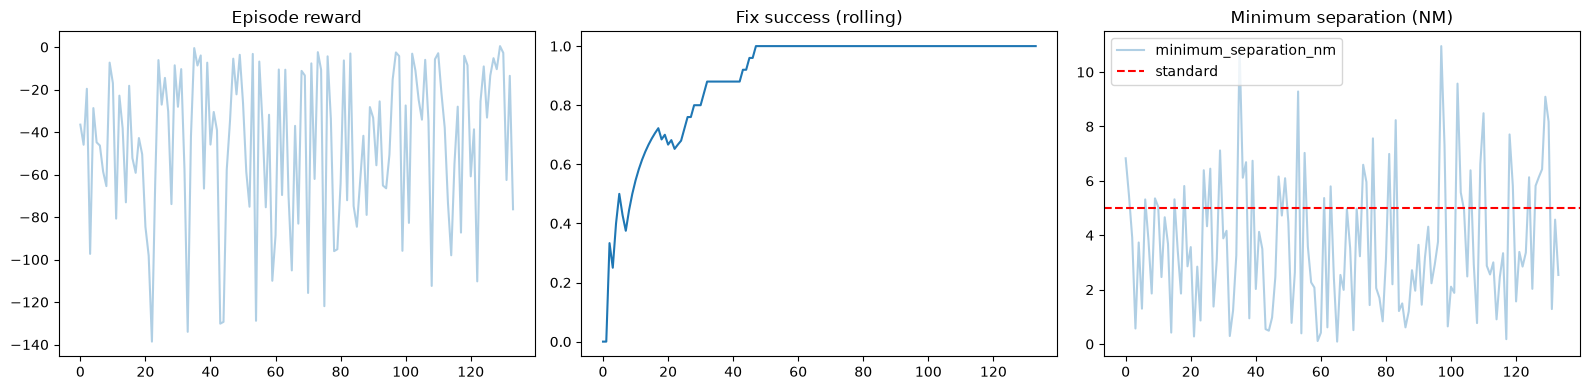

In [6]:
training = pd.DataFrame(callback.episodes)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
training['reward'].plot(ax=axes[0], alpha=0.35, title='Episode reward')
training['reached_fix'].astype(int).rolling(25, min_periods=1).mean().plot(ax=axes[1], title='Fix success (rolling)')
training['minimum_separation_nm'].plot(ax=axes[2], alpha=0.35, title='Minimum separation (NM)')
axes[2].axhline(5.0, color='red', linestyle='--', label='standard')
axes[2].legend()
plt.tight_layout()
plot_training_progress(callback.episodes, OUTPUT_DIR / 'training_progress.png')

## 5. Held-out evaluation

Evaluation uses deterministic actions and the same seeds as the random baseline. For a final claim, use a larger held-out seed range and repeat the selected configuration with nominal timing.

In [7]:
ppo_records = quiet_call(evaluate_policy, model, evaluation_seeds, action_freq=ACTION_FREQ, dt=DT)
ppo_summary = summarize_metrics(ppo_records)
comparison = pd.DataFrame([random_summary, ppo_summary], index=['Random', 'PPO'])
comparison

,episodes,success_rate,mean_reward,std_reward,mean_intrusions,mean_minimum_separation_nm,unsafe_episode_rate,mean_average_drift,mean_steps
Random,10,0.0,-68.343811,25.574654,15.1,3.832309,0.7,1.818776,200.0
PPO,10,1.0,-63.732341,54.070880,43.0,2.698555,0.8,0.329865,44.3


## 6. Step-by-step trajectory comparison

The plot is a qualitative check: it shows whether PPO reaches the fix by making controlled corrections and whether intruders enter the ownship separation zone. These examples use a farther 60–80 km (32–43 NM) spawn range to show more of the approach; baseline metrics still use the standard 30–50 km range. The view is framed around the ownship path and FAF so the control behavior remains readable; distant intruder segments may be clipped. Quantitative metrics remain the primary evidence.

In [8]:
comparison_examples = []
for example_index, example_seed in enumerate(evaluation_seeds[:3], start=1):
    ppo_example = quiet_call(
        run_episode, model, example_seed, action_freq=ACTION_FREQ, dt=DT,
        spawn_distance_min=EXAMPLE_SPAWN_DISTANCE_MIN,
        spawn_distance_max=EXAMPLE_SPAWN_DISTANCE_MAX,
    )
    random_example = quiet_call(
        run_episode, None, example_seed, action_freq=ACTION_FREQ, dt=DT,
        spawn_distance_min=EXAMPLE_SPAWN_DISTANCE_MIN,
        spawn_distance_max=EXAMPLE_SPAWN_DISTANCE_MAX,
    )
    comparison_examples.append((ppo_example, random_example))
    image_name = 'ppo_vs_random.png' if example_index == 1 else f'ppo_vs_random_example_{example_index}.png'
    plot_comparison(ppo_example, random_example, OUTPUT_DIR / image_name)

ppo_episode, random_episode = comparison_examples[0]
plot_interactive_comparison(ppo_episode, random_episode, OUTPUT_DIR / 'ppo_vs_random_interactive.html')
print('Saved three matched trajectory examples to', OUTPUT_DIR)
print('Saved:', OUTPUT_DIR / 'ppo_vs_random_interactive.html')

Saved three matched trajectory examples to /home/mbatacan/git/github/Air-Collision-Avoidance-Project/runs/ppo_phase1_notebook
Saved: /home/mbatacan/git/github/Air-Collision-Avoidance-Project/runs/ppo_phase1_notebook/ppo_vs_random_interactive.html


## 7. Curved-intruder robustness preview

The reproducible PPO baseline keeps straight-line intruders. This separate preview gives intruders randomized, smooth routes that still end at the FAF. It tests whether the trained policy remains sensible under modest motion variation; it is not used to retrain or select the Phase 1 baseline.

reward  reached_fix  total_intrusions  minimum_separation_nm  \
seed policy                                                                    
1000 PPO    -99.564544         True                64               1.455116   
     Random -81.856802        False                25               2.663318   
1001 PPO    -25.085607         True                15               2.951507   
     Random -32.163809        False                 0               8.467828   
1002 PPO    -84.680506         True                54               2.082688   
     Random -64.470264        False                20               0.530137   

             average_drift  steps  terminated  truncated reward_profile  
seed policy                                                              
1000 PPO          0.374113    102        True      False       baseline  
     Random       1.912691    200       False       True       baseline  
1001 PPO          0.402699    106        True      False       baseline  
     Random       1.411988    200       False       True       baseline  
1002 PPO          0.392983     98        True      False       baseline  
     Random       1.585155    200       False       True       baseline

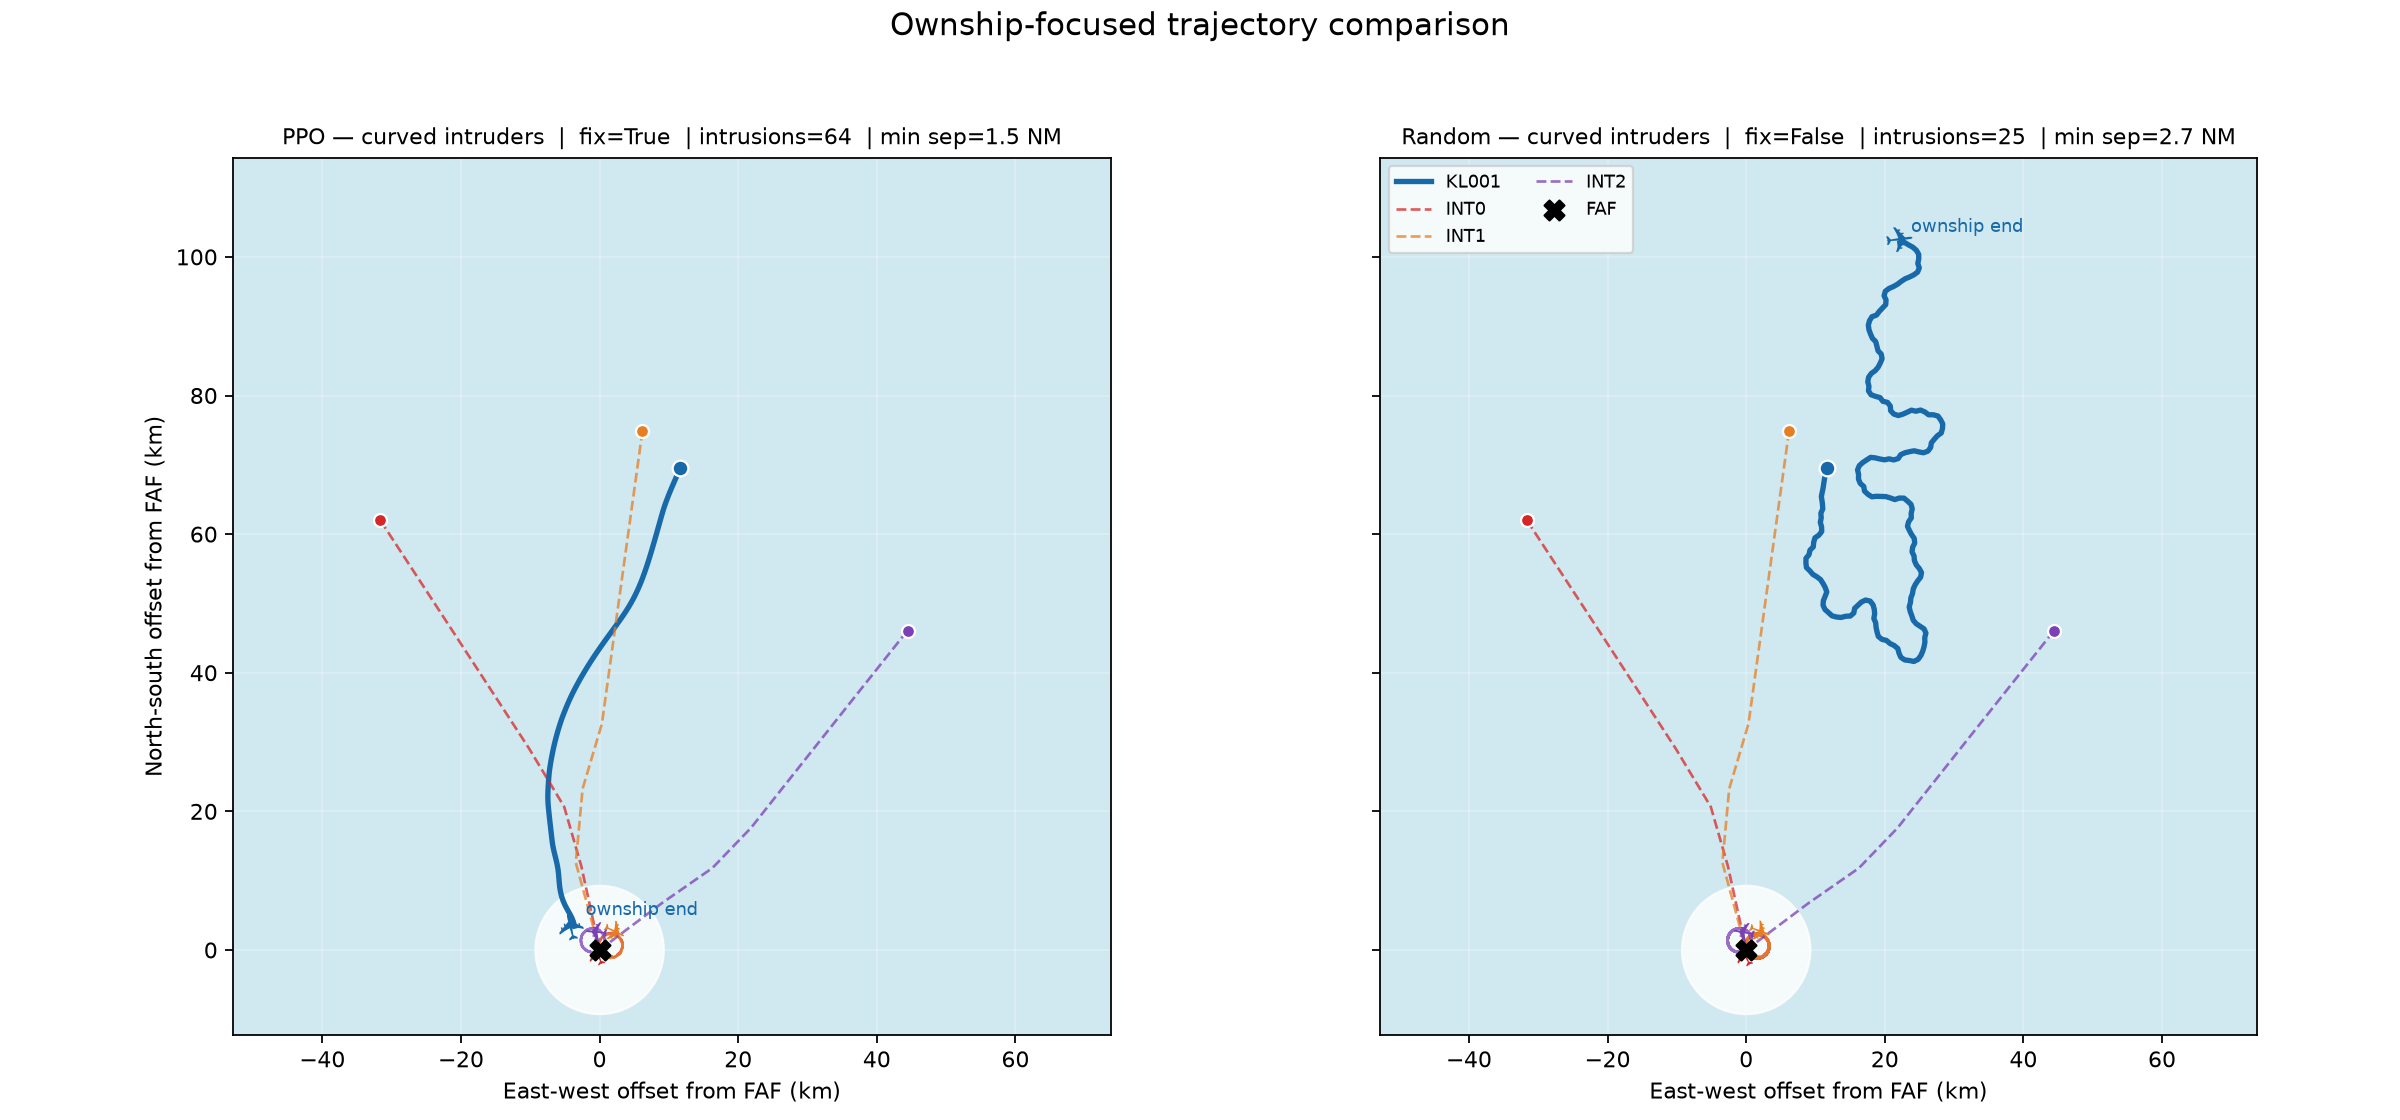

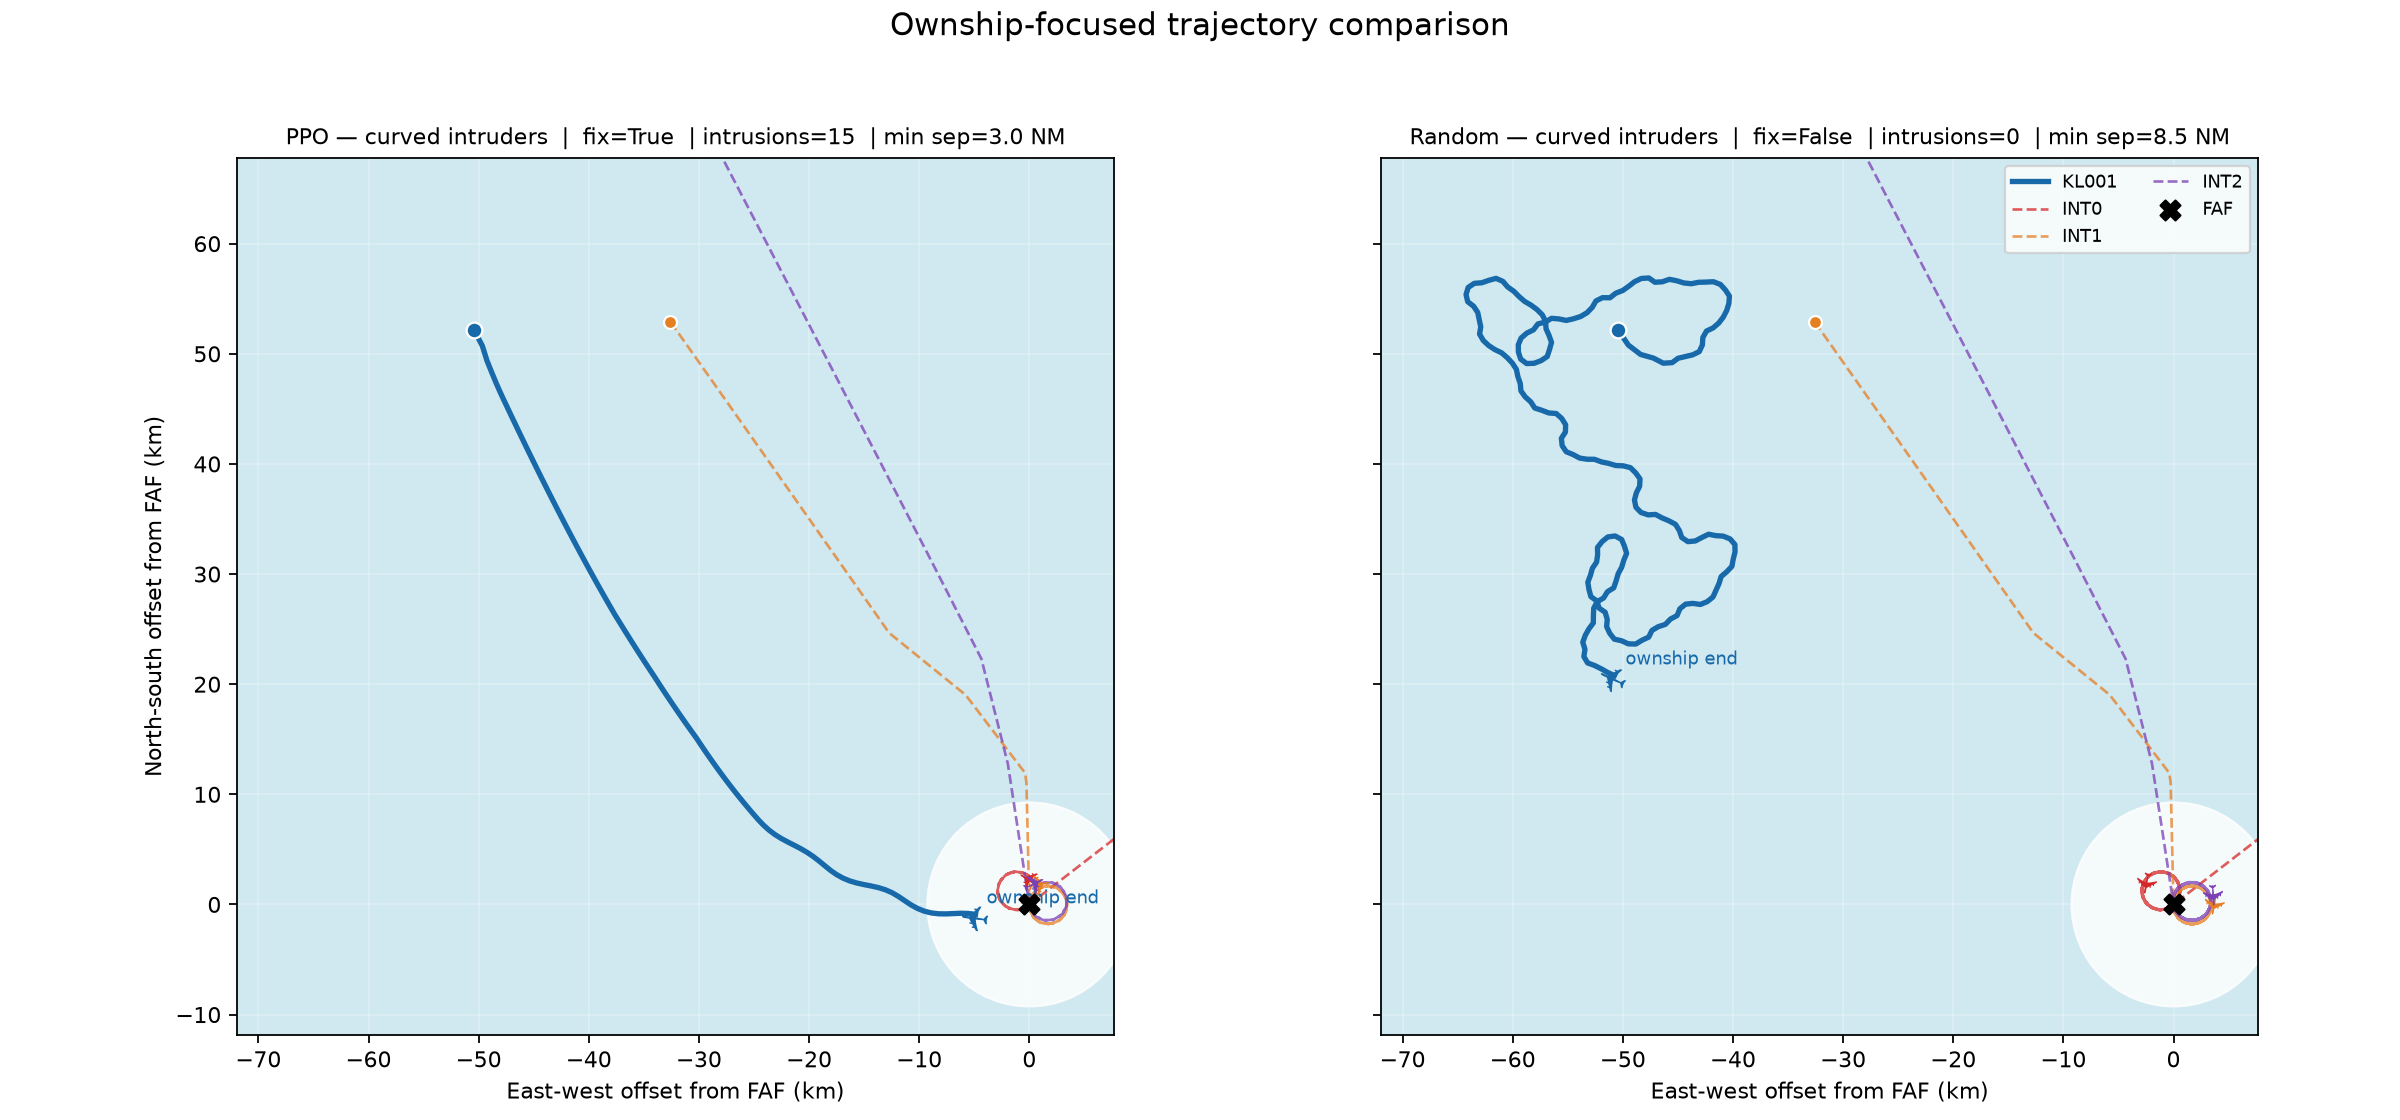

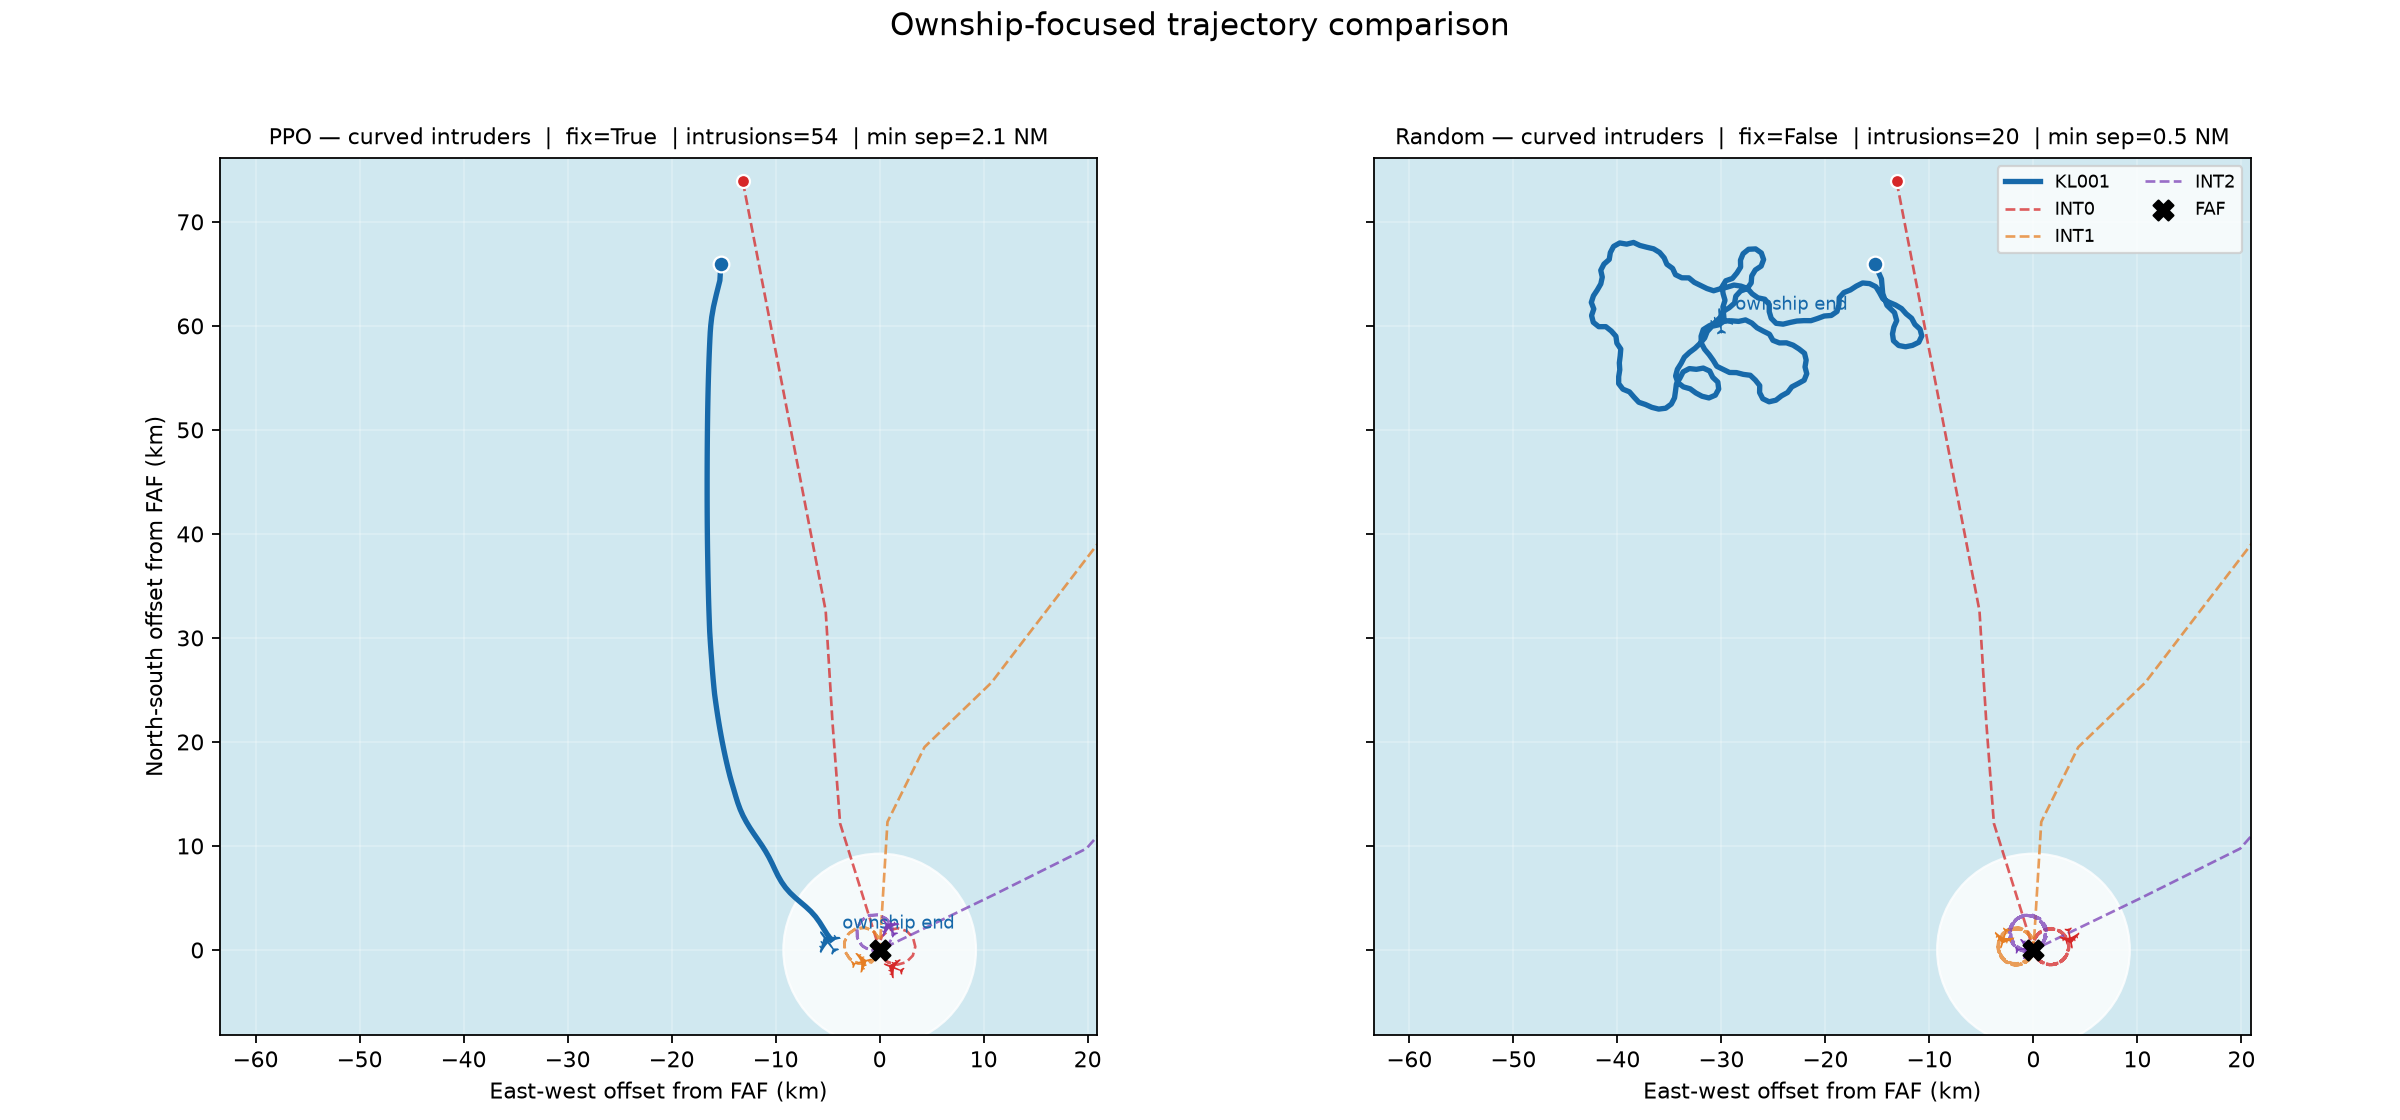

Saved three curved-intruder examples to /home/mbatacan/git/github/Air-Collision-Avoidance-Project/runs/ppo_phase1_notebook/curved_intruder_preview


In [9]:
from IPython.display import Image, display
CURVED_OUTPUT_DIR = OUTPUT_DIR / 'curved_intruder_preview'
curved_examples = []
curved_results = []
for example_index, example_seed in enumerate(evaluation_seeds[:3], start=1):
    curved_ppo = quiet_call(
        run_episode, model, example_seed, action_freq=ACTION_FREQ, dt=DT,
        intruder_behavior='curved',
        spawn_distance_min=EXAMPLE_SPAWN_DISTANCE_MIN,
        spawn_distance_max=EXAMPLE_SPAWN_DISTANCE_MAX,
    )
    curved_random = quiet_call(
        run_episode, None, example_seed, action_freq=ACTION_FREQ, dt=DT,
        intruder_behavior='curved',
        spawn_distance_min=EXAMPLE_SPAWN_DISTANCE_MIN,
        spawn_distance_max=EXAMPLE_SPAWN_DISTANCE_MAX,
    )
    curved_examples.append((curved_ppo, curved_random))
    curved_results.extend([
        {'seed': example_seed, 'policy': 'PPO', **curved_ppo[0]},
        {'seed': example_seed, 'policy': 'Random', **curved_random[0]},
    ])
    image_name = 'ppo_vs_random_curved_intruders.png' if example_index == 1 else f'ppo_vs_random_curved_intruders_{example_index}.png'
    plot_comparison(
        curved_ppo, curved_random, CURVED_OUTPUT_DIR / image_name,
        labels=('PPO — curved intruders', 'Random — curved intruders'),
    )

curved_ppo_episode, curved_random_episode = curved_examples[0]
plot_interactive_comparison(
    curved_ppo_episode, curved_random_episode,
    CURVED_OUTPUT_DIR / 'ppo_vs_random_curved_intruders.html',
    labels=('PPO — curved intruders', 'Random — curved intruders'),
)
display(pd.DataFrame(curved_results).set_index(['seed', 'policy']))
for example_index in range(1, 4):
    image_name = 'ppo_vs_random_curved_intruders.png' if example_index == 1 else f'ppo_vs_random_curved_intruders_{example_index}.png'
    display(Image(filename=str(CURVED_OUTPUT_DIR / image_name)))
print('Saved three curved-intruder examples to', CURVED_OUTPUT_DIR)

## 8. Output comparison and interactive artifact

This is the compact result view to include in progress updates. The table keeps PPO and Random paired on the same seeds; the image shows the geographic behavior; the HTML artifact can be stepped through one agent decision at a time.

,episodes,success_rate,mean_reward,std_reward,mean_intrusions,mean_minimum_separation_nm,unsafe_episode_rate,mean_average_drift,mean_steps
Random,10,0.0%,-68.34,25.574654,15.10,3.83,70.0%,1.82,200.0
PPO,10,100.0%,-63.73,54.070880,43.00,2.70,80.0%,0.33,44.3


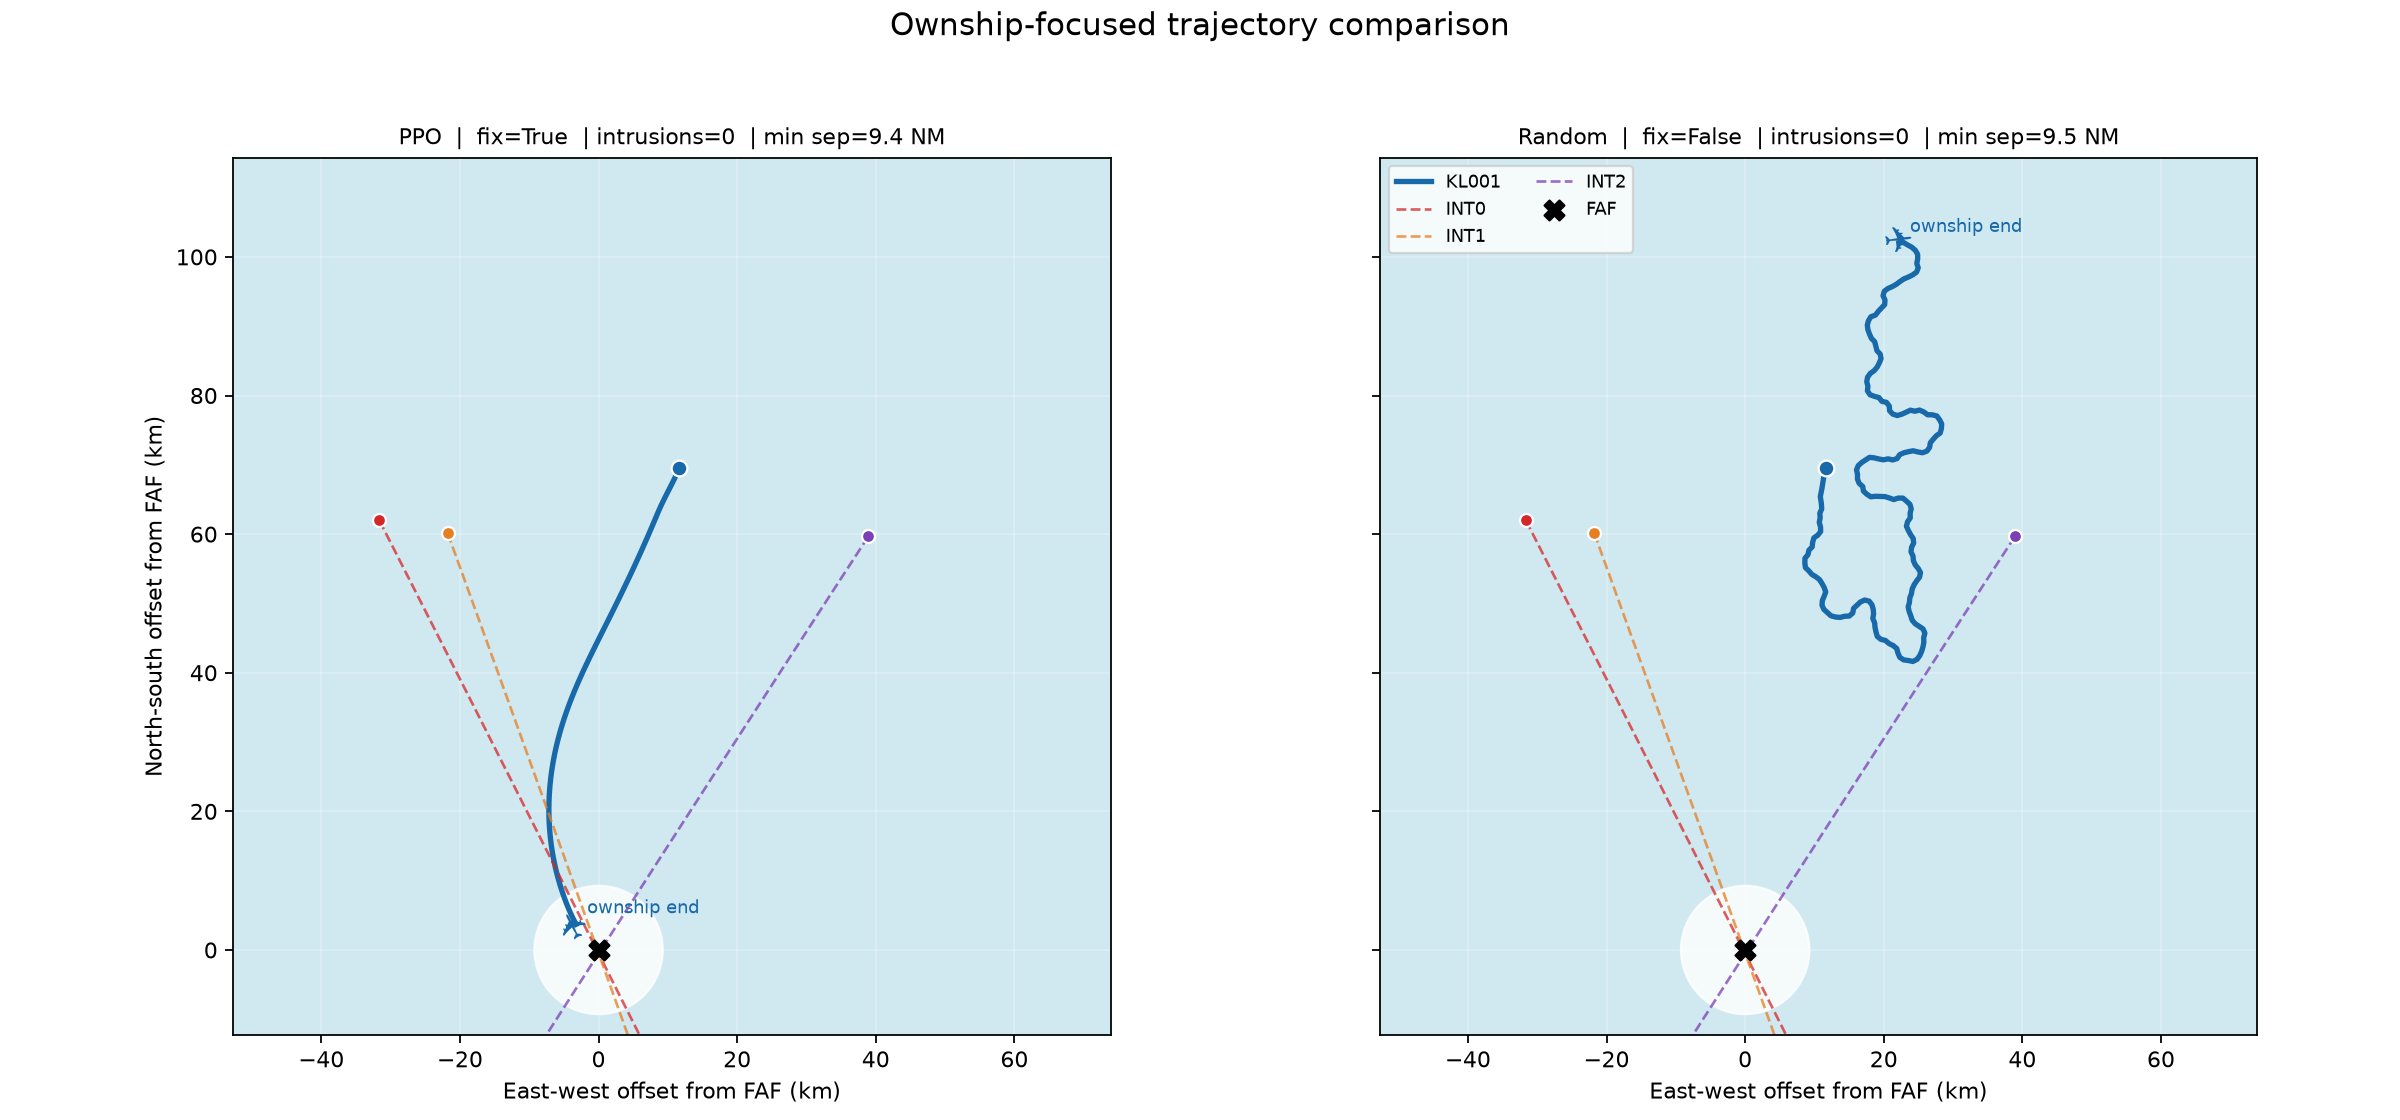

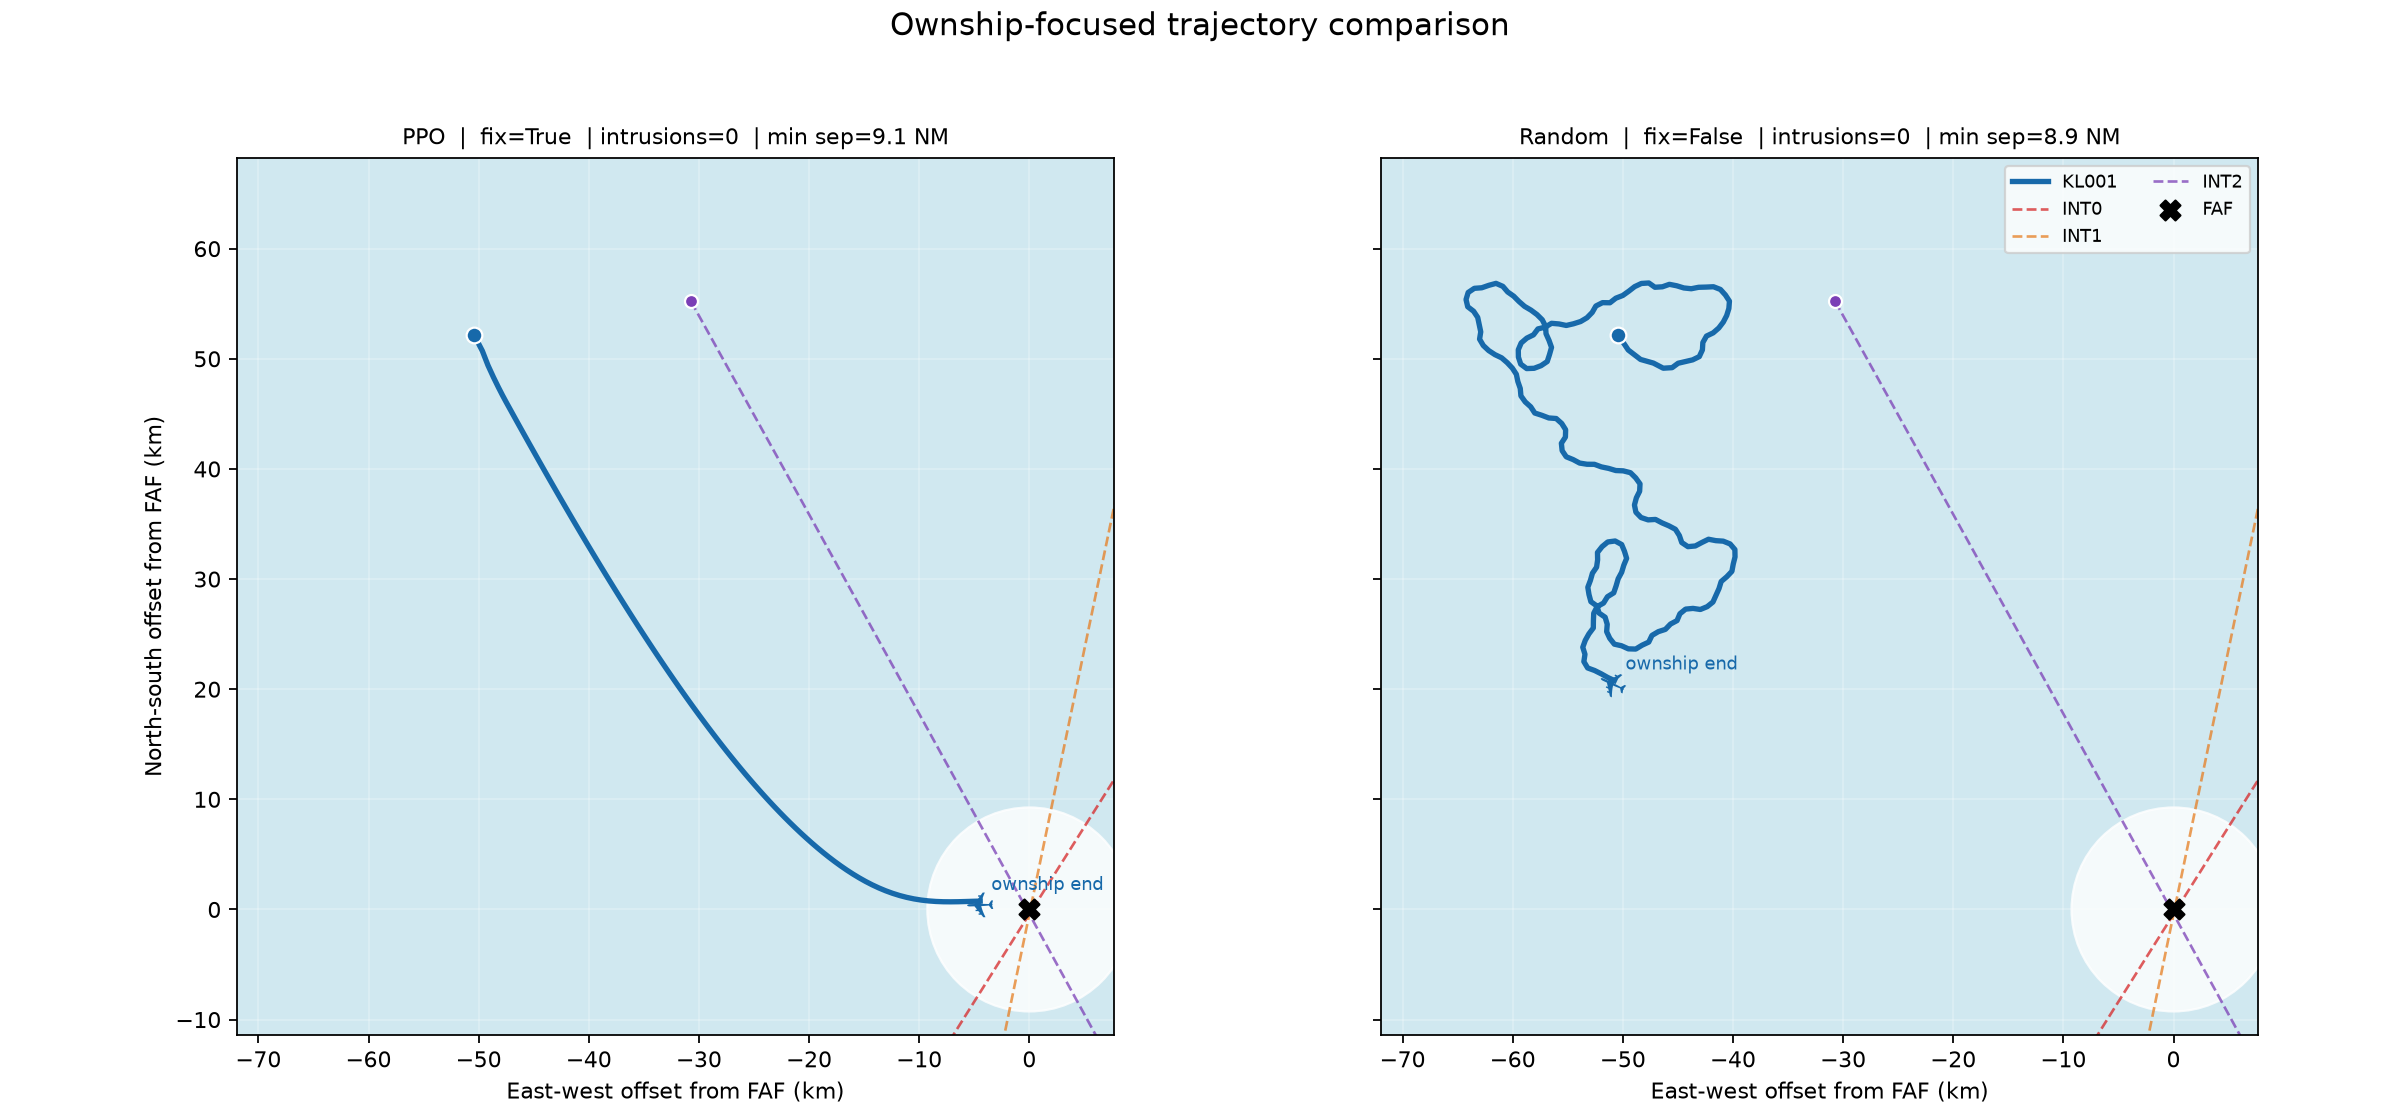

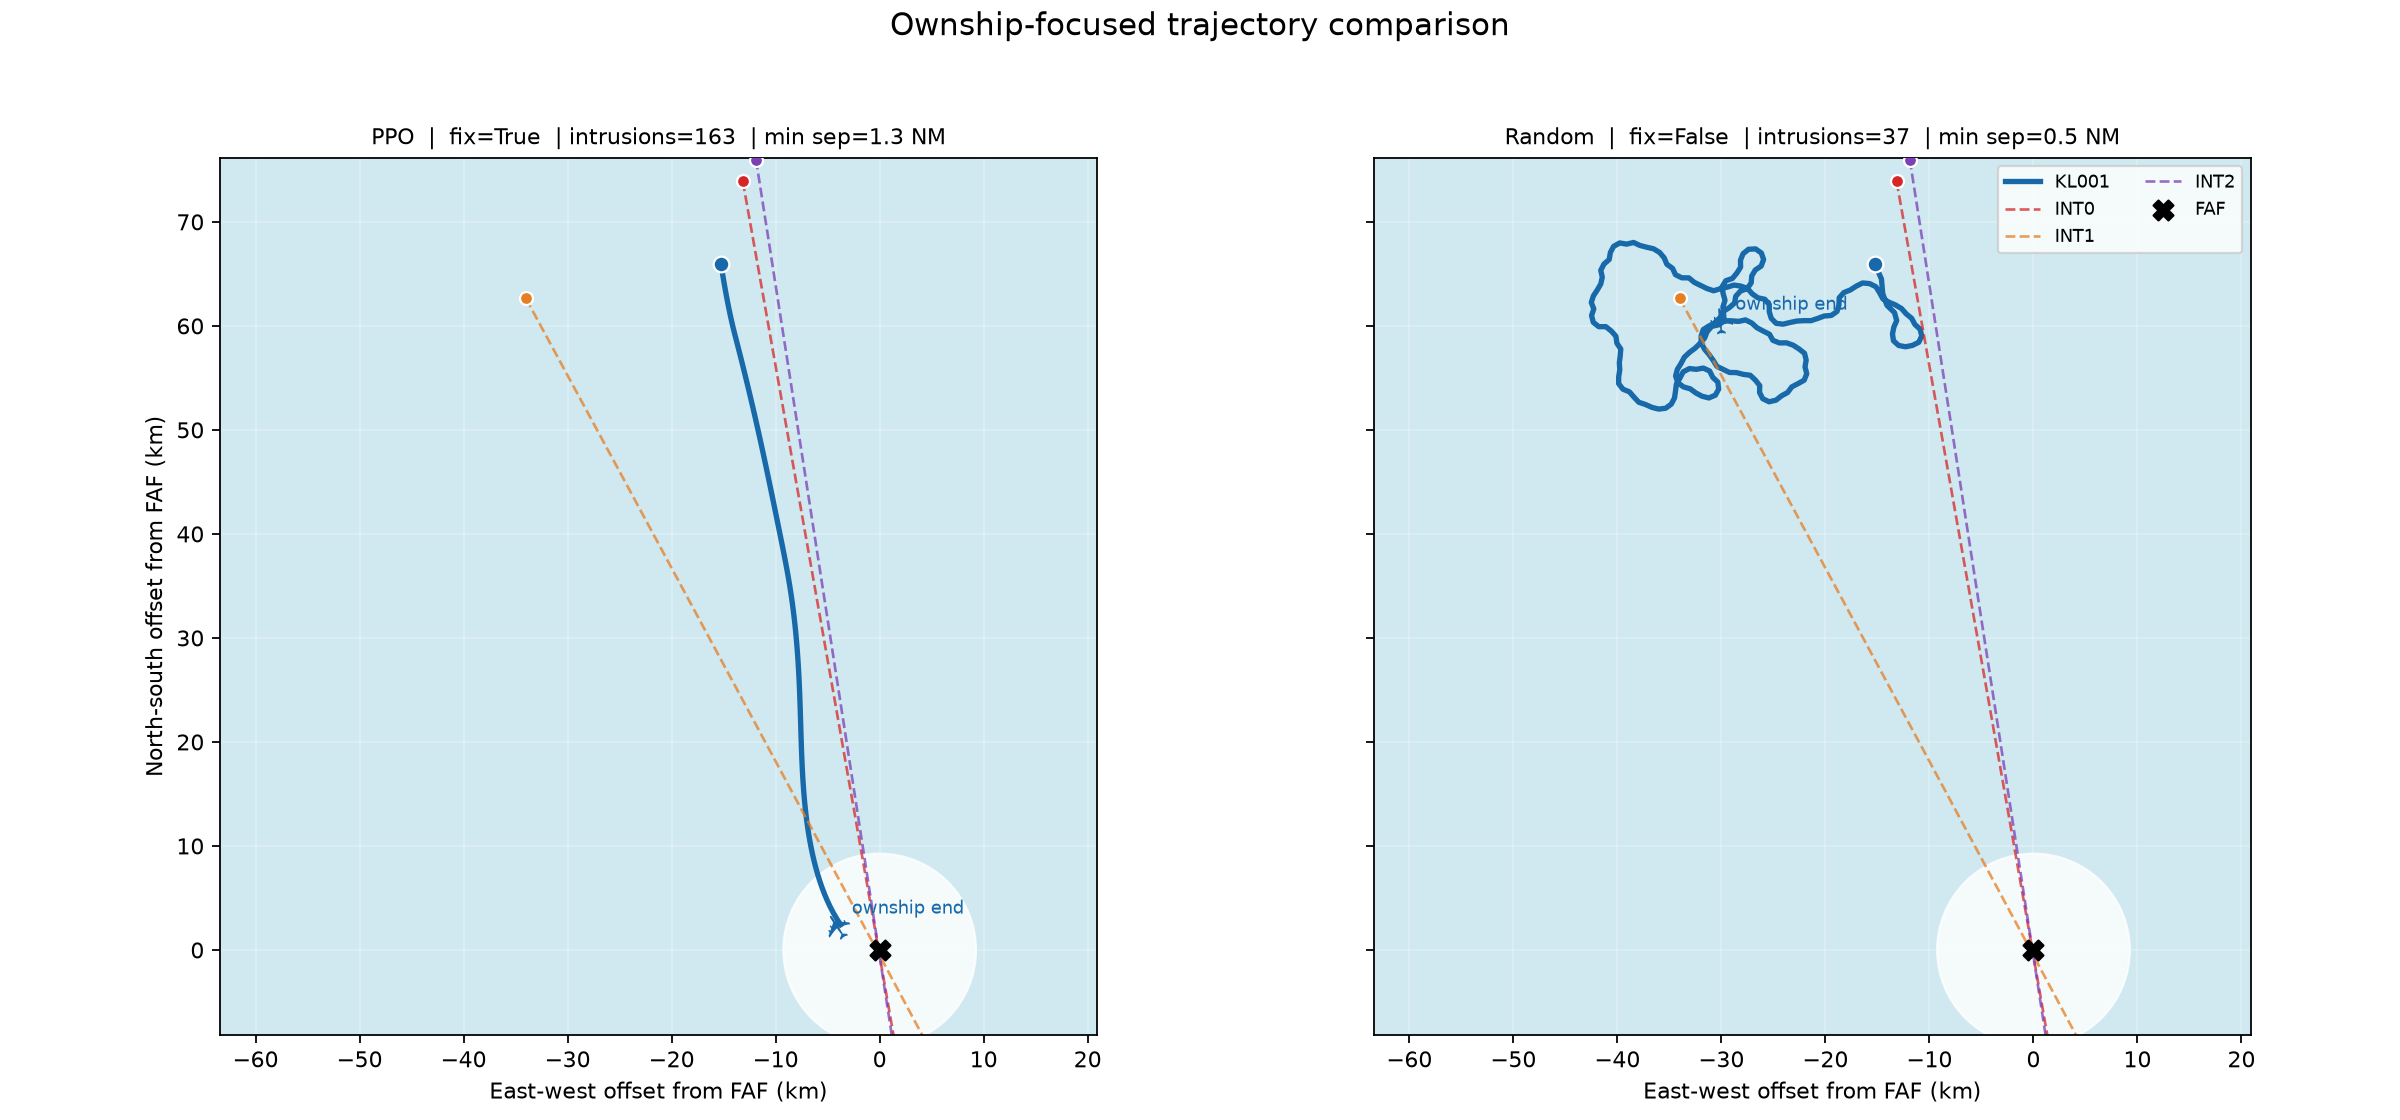

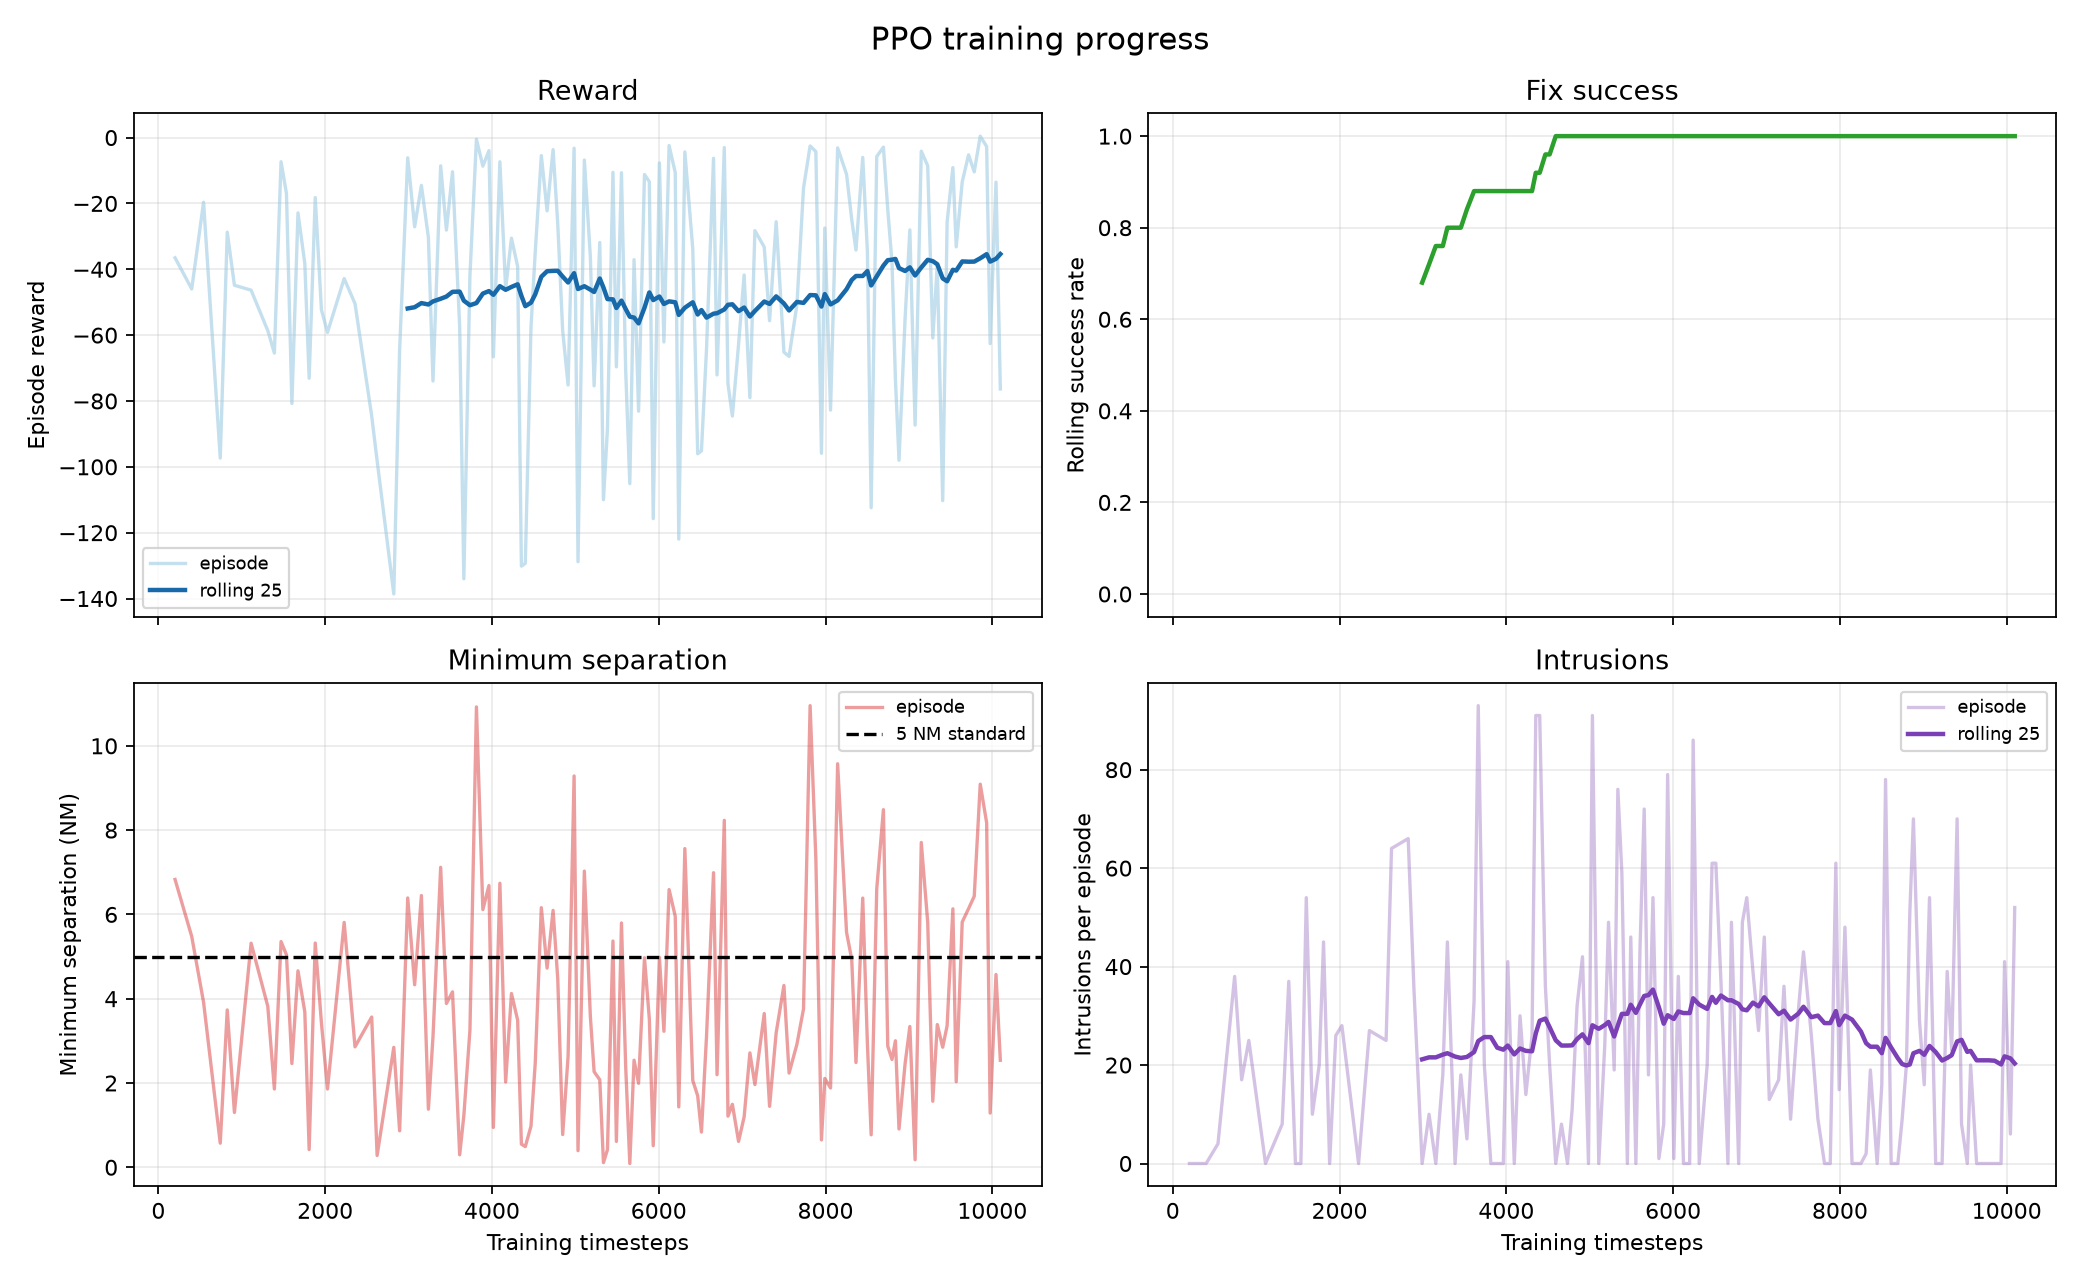

In [10]:
from IPython.display import Image, IFrame, display

display(comparison.style.format({
    'success_rate': '{:.1%}',
    'mean_reward': '{:.2f}',
    'mean_intrusions': '{:.2f}',
    'mean_minimum_separation_nm': '{:.2f}',
    'unsafe_episode_rate': '{:.1%}',
    'mean_average_drift': '{:.2f}',
    'mean_steps': '{:.1f}',
}))
for example_index in range(1, 4):
    image_name = 'ppo_vs_random.png' if example_index == 1 else f'ppo_vs_random_example_{example_index}.png'
    display(Image(filename=str(OUTPUT_DIR / image_name)))
display(Image(filename=str(OUTPUT_DIR / 'training_progress.png')))
display(IFrame(src=str(OUTPUT_DIR / 'ppo_vs_random_interactive.html'), width='100%', height=720))

## 9. Next step preview: nominal timing

The fast setting is useful for iteration, but the next defensible check is to run the same trained policy at nominal timing (`action_freq=10`, `dt=5`) on the same held-out seeds. This isolates the effect of simulation timing before changing rewards or intruder behavior.

In [11]:
NOMINAL_ACTION_FREQ = 10
NOMINAL_DT = 5.0
nominal_random_records = quiet_call(evaluate_policy, None, evaluation_seeds, action_freq=NOMINAL_ACTION_FREQ, dt=NOMINAL_DT)
nominal_ppo_records = quiet_call(evaluate_policy, model, evaluation_seeds, action_freq=NOMINAL_ACTION_FREQ, dt=NOMINAL_DT)
nominal_comparison = pd.DataFrame([
    summarize_metrics(nominal_random_records),
    summarize_metrics(nominal_ppo_records),
], index=['Random — nominal', 'PPO — nominal'])
nominal_comparison.style.format({
    'success_rate': '{:.1%}',
    'mean_reward': '{:.2f}',
    'mean_intrusions': '{:.2f}',
    'mean_minimum_separation_nm': '{:.2f}',
    'unsafe_episode_rate': '{:.1%}',
    'mean_average_drift': '{:.2f}',
    'mean_steps': '{:.1f}',
})

,episodes,success_rate,mean_reward,std_reward,mean_intrusions,mean_minimum_separation_nm,unsafe_episode_rate,mean_average_drift,mean_steps
Random — nominal,10,50.0%,-46.21,34.392046,8.30,2.51,90.0%,1.33,115.7
PPO — nominal,10,100.0%,-11.58,10.572449,9.60,2.41,80.0%,0.43,9.3


## 10. Research roadmap after the nominal check

1. **Safety-first reward study:** compare the current reward with stronger proximity/separation shaping, keeping the environment and seed list fixed.
2. **Controlled PPO sensitivity:** vary rollout length, entropy coefficient, and training budget one factor at a time; select on unsafe-episode rate before fix success.
3. **Larger held-out evaluation:** repeat the selected configuration over at least 50 seeds with confidence intervals.
4. **More realistic intruders:** introduce waypoint or turn-rate behavior as a separate environment experiment only after the 2D safety baseline improves.
5. **Phase 2:** extend the accepted PPO policy to altitude and glideslope control.

## 11. Safety-first reward comparison

This is a small Phase 1 exploration, not a final model selection. It trains the unchanged baseline and the separate `safety_shaping` profile on the same fast BlueSky configuration and held-out seeds. Safety metrics are considered before fix success.

In [12]:
SAFETY_OUTPUT_DIR = PROJECT_ROOT / 'runs/ppo_safety_notebook'
SAFETY_TIMESTEPS = 2_048
safety_results = {}
safety_episodes = {}
safety_training = {}
for reward_profile in ('baseline', 'safety_shaping'):
    profile_dir = SAFETY_OUTPUT_DIR / reward_profile
    profile_dir.mkdir(parents=True, exist_ok=True)
    safety_env = quiet_call(make_env, action_freq=ACTION_FREQ, dt=DT, reward_profile=reward_profile)
    quiet_call(safety_env.reset, seed=SEED)
    safety_callback = PPOEpisodeCallback()
    safety_model = make_ppo_model(safety_env, seed=SEED, verbose=0)
    quiet_call(safety_model.learn, total_timesteps=SAFETY_TIMESTEPS, callback=safety_callback)
    safety_model.save(str(profile_dir / 'ppo_phase1_bluesky'))
    safety_env.close()
    safety_training[reward_profile] = safety_callback.episodes
    plot_training_progress(
        safety_callback.episodes, profile_dir / 'training_progress.png',
        title=f'PPO training progress — {reward_profile}',
    )
    safety_results[reward_profile] = quiet_call(evaluate_policy,
        safety_model, evaluation_seeds, action_freq=ACTION_FREQ, dt=DT,
        reward_profile=reward_profile,
    )
    safety_episodes[reward_profile] = quiet_call(run_episode,
        safety_model, evaluation_seeds[0], ACTION_FREQ, DT, reward_profile
    )

safety_comparison = pd.DataFrame(
    [summarize_metrics(safety_results[name]) for name in safety_results],
    index=['PPO baseline', 'PPO safety shaping'],
)
safety_comparison.style.format({
    'success_rate': '{:.1%}',
    'mean_reward': '{:.2f}',
    'mean_intrusions': '{:.2f}',
    'mean_minimum_separation_nm': '{:.2f}',
    'unsafe_episode_rate': '{:.1%}',
    'mean_average_drift': '{:.2f}',
    'mean_steps': '{:.1f}',
})

,episodes,success_rate,mean_reward,std_reward,mean_intrusions,mean_minimum_separation_nm,unsafe_episode_rate,mean_average_drift,mean_steps
PPO baseline,10,100.0%,-85.13,45.786515,57.10,1.94,80.0%,0.38,45.9
PPO safety shaping,10,100.0%,-409.08,208.267587,60.20,1.74,90.0%,0.28,43.7


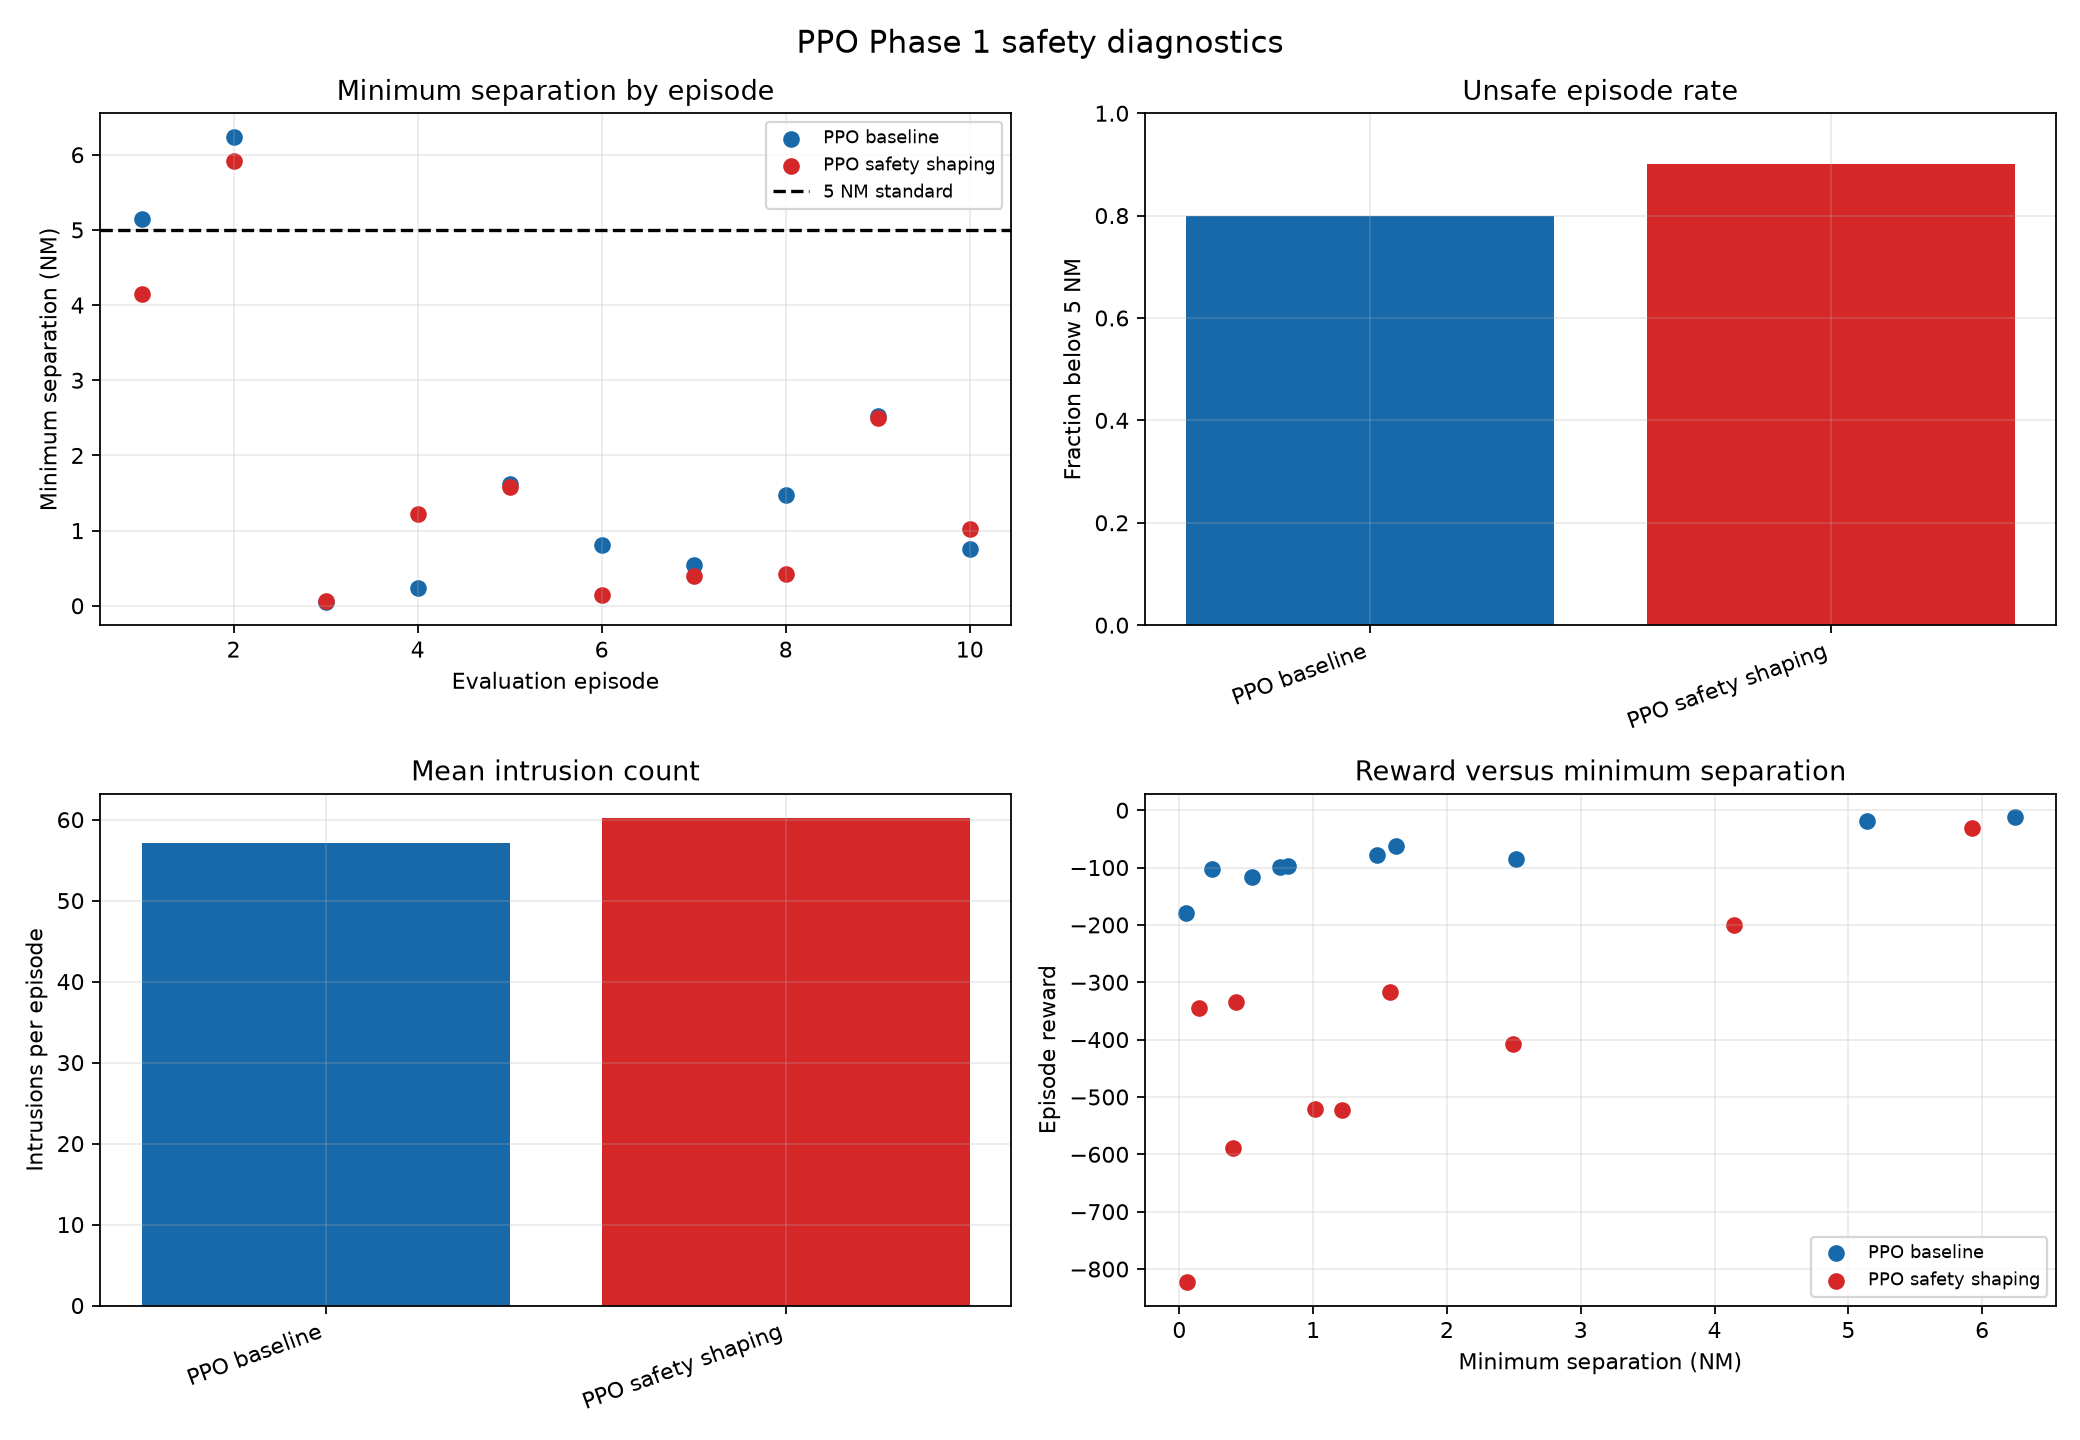

Saved safety artifacts to /home/mbatacan/git/github/Air-Collision-Avoidance-Project/runs/ppo_safety_notebook


In [13]:
from IPython.display import Image, display

plot_safety_diagnostics(
    {'PPO baseline': safety_results['baseline'],
     'PPO safety shaping': safety_results['safety_shaping']},
    SAFETY_OUTPUT_DIR / 'safety_diagnostics.png',
)
plot_action_and_separation(
    safety_episodes['safety_shaping'][1],
    SAFETY_OUTPUT_DIR / 'safety_action_trace.png',
    'Safety-shaped PPO — action and separation by decision',
)
plot_comparison(
    safety_episodes['baseline'], safety_episodes['safety_shaping'],
    SAFETY_OUTPUT_DIR / 'ppo_baseline_vs_safety.png',
    labels=('PPO baseline', 'PPO safety shaping'),
)
plot_interactive_comparison(
    safety_episodes['baseline'], safety_episodes['safety_shaping'],
    SAFETY_OUTPUT_DIR / 'ppo_baseline_vs_safety_interactive.html',
    labels=('PPO baseline', 'PPO safety shaping'),
)
display(Image(filename=str(SAFETY_OUTPUT_DIR / 'safety_diagnostics.png')))
print('Saved safety artifacts to', SAFETY_OUTPUT_DIR)

## Next research steps

- Repeat the experiment with a larger held-out seed set.
- Run a one-factor-at-a-time sensitivity study over rollout length, entropy coefficient, and training budget.
- Confirm the selected policy at nominal BlueSky timing (`action_freq=10`, `dt=5`).
- Use the Plotly decision-step artifact to inspect unsafe policy behavior before changing the straight-path intruder assumption.
- Only then replace straight intruder paths with waypoint/turn-rate models.